# 🌞 Solar Panel Detection from Satellite Imagery
## Clean Discussion Version — Custom YOLO-Style CNN + YOLOv5 Transfer Learning

**Dataset:** PV01 subset from the Multi-Resolution PV Panel Segmentation Dataset  
**Main goal:** detect solar panels in satellite/aerial images.  
**Approach:**

1. Read images and segmentation masks.
2. Convert masks into bounding boxes.
3. Train a custom YOLO-style CNN from scratch in PyTorch.
4. Evaluate Precision, Recall, and F1 using different confidence thresholds.
5. Compare the custom model with YOLOv5s trained using pretrained weights.

### Main discussion points

| Topic | What to say |
|---|---|
| Mask → boxes | The original labels are segmentation masks, so we convert each connected white region into one bounding box. |
| Custom model | The model predicts one box per grid cell, similar to the YOLO idea. |
| Early stopping | Training stops when validation loss stops improving, which reduces overfitting. |
| Threshold search | We test confidence thresholds and choose the one with the best F1 score. |
| YOLOv5 comparison | YOLOv5 uses pretrained weights, so it is usually stronger than training a small detector from scratch. |


## 1. Imports, configuration, and reproducibility

This section keeps all imports, constants, paths, and random seeds in one place. This makes the notebook easier to discuss and easier to edit later.


In [120]:
import os
import random
import shutil
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageEnhance
from scipy import ndimage

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Device
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Name   : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# -----------------------------
# Project paths
# -----------------------------
WORKING_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
PROJECT_DIR = WORKING_DIR / "solar_project"
DATA_DIR = PROJECT_DIR / "data"
LABELS_DIR = DATA_DIR / "labels"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"

for folder in [DATA_DIR, LABELS_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Experiment settings
# -----------------------------
IMAGE_SIZE = 256
GRID_SIZE = 16
MAX_BOXES = 36
BATCH_SIZE = 16
CLASS_ID = 0
CLASS_NAME = "solar_panel"

print("✅ Setup complete")
print(f"Project directory: {PROJECT_DIR}")


Using device: cuda
GPU Name   : Tesla T4
GPU Memory : 15.64 GB
✅ Setup complete
Project directory: /kaggle/working/solar_project


## 2. Locate the PV01 dataset

Kaggle datasets are usually mounted under `/kaggle/input`. The code below searches automatically for the folder that contains the most valid image/mask pairs.

A valid pair means:

- image file: `something.bmp`
- mask file: `something_label.bmp`


In [121]:
def count_pv_pairs(root):
    """Count .bmp images that have a matching *_label.bmp mask."""
    root = Path(root)
    if not root.exists():
        return 0

    count = 0
    for img_path in root.rglob("*.bmp"):
        if "_label" in img_path.name:
            continue
        if img_path.with_name(f"{img_path.stem}_label.bmp").exists():
            count += 1
    return count


def find_dataset_root():
    """Find the most likely PV01 dataset root in Kaggle or local folders."""
    kaggle_input = Path("/kaggle/input")
    local_fallback = DATA_DIR / "raw" / "PV01"

    candidates = []
    if kaggle_input.exists():
        print("📁 Kaggle input folders:")
        for item in sorted(kaggle_input.iterdir()):
            print(f"   {item}")

        candidates.extend([p for p in kaggle_input.rglob("PV01") if p.is_dir()])
        candidates.extend([p for p in kaggle_input.iterdir() if p.is_dir()])

    candidates.append(local_fallback)

    # Remove duplicates while keeping order
    unique_candidates = list(dict.fromkeys(map(Path, candidates)))
    scored = sorted(
        [(count_pv_pairs(path), path) for path in unique_candidates],
        key=lambda x: x[0],
        reverse=True
    )

    if not scored or scored[0][0] == 0:
        raise FileNotFoundError(
            "No PV01 image/mask pairs were found. Add the dataset to the Kaggle notebook first."
        )

    return scored[0][1], scored[0][0]


RAW_ROOT, pair_count = find_dataset_root()
print("\n✅ Dataset found")
print(f"RAW_ROOT      : {RAW_ROOT}")
print(f"Paired samples: {pair_count}")


📁 Kaggle input folders:
   /kaggle/input/datasets

✅ Dataset found
RAW_ROOT      : /kaggle/input/datasets/mahmoudkhaledd0/pv01-solar-panel-dataset/PV01
Paired samples: 645


## 3. Load image/mask pairs

This cell builds two aligned lists:

- `image_paths[i]` = image path
- `mask_paths[i]` = matching mask path


In [122]:
def collect_pairs(root):
    """Return aligned image and mask path lists."""
    images, masks = [], []
    for img_path in sorted(Path(root).rglob("*.bmp")):
        if "_label" in img_path.name:
            continue

        mask_path = img_path.with_name(f"{img_path.stem}_label.bmp")
        if mask_path.exists():
            images.append(img_path)
            masks.append(mask_path)
    return images, masks


image_paths, mask_paths = collect_pairs(RAW_ROOT)

if not image_paths:
    raise RuntimeError(f"No image/mask pairs found in {RAW_ROOT}")

print(f"✅ Total paired samples: {len(image_paths)}")
print(f"Example image: {image_paths[0]}")
print(f"Example mask : {mask_paths[0]}")


✅ Total paired samples: 645
Example image: /kaggle/input/datasets/mahmoudkhaledd0/pv01-solar-panel-dataset/PV01/PV01_Rooftop_Brick/PV01_324942_1203839.bmp
Example mask : /kaggle/input/datasets/mahmoudkhaledd0/pv01-solar-panel-dataset/PV01/PV01_Rooftop_Brick/PV01_324942_1203839_label.bmp


## 4. Visualize image/mask samples

This is a quick sanity check. The mask should highlight the solar panels in white.


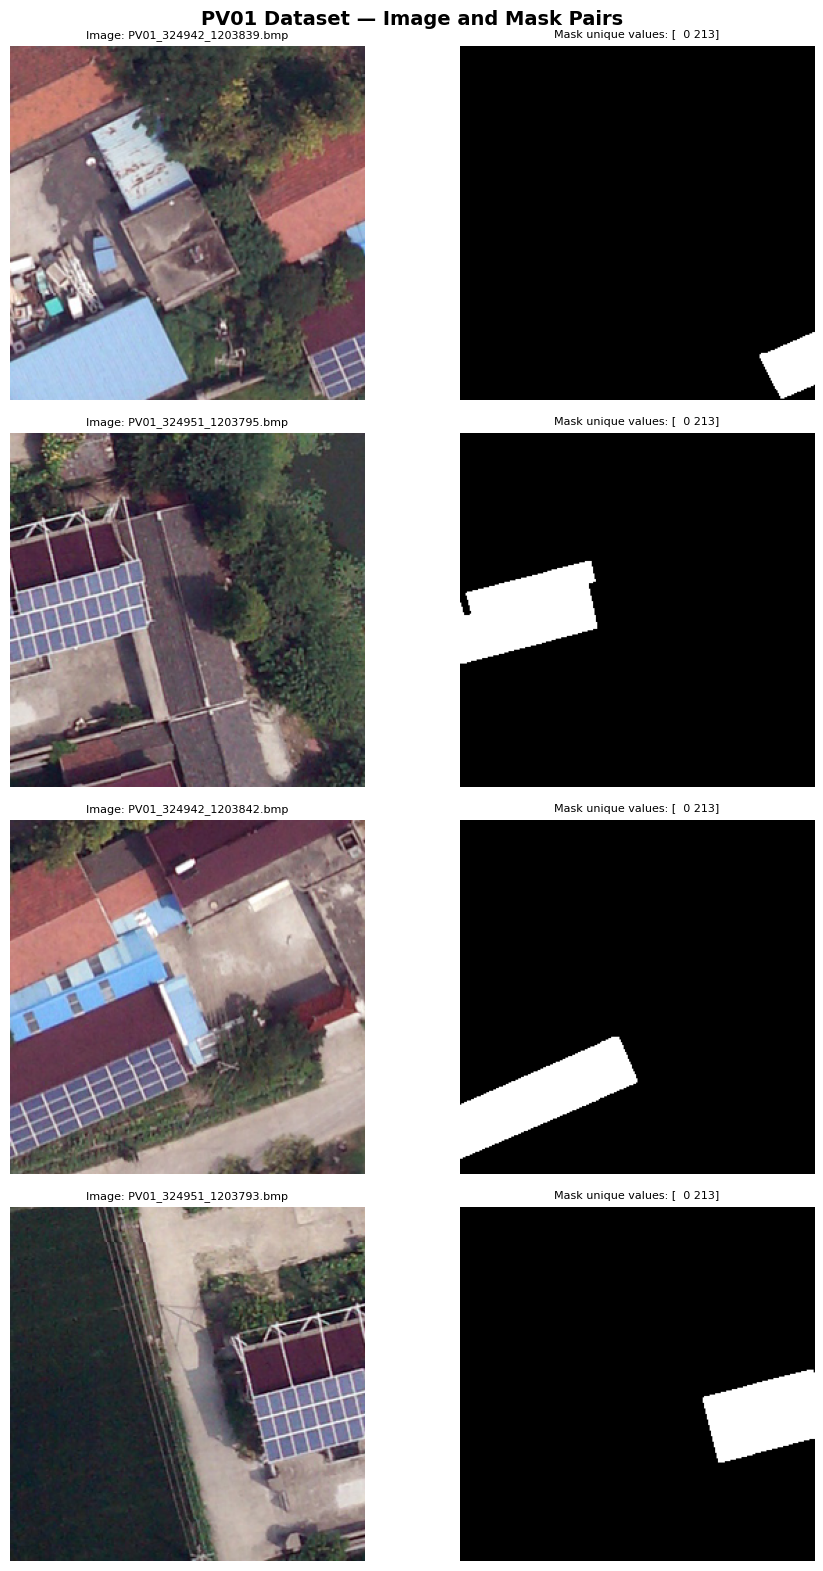

✅ Saved: /kaggle/working/solar_project/results/step1_image_mask_pairs.png


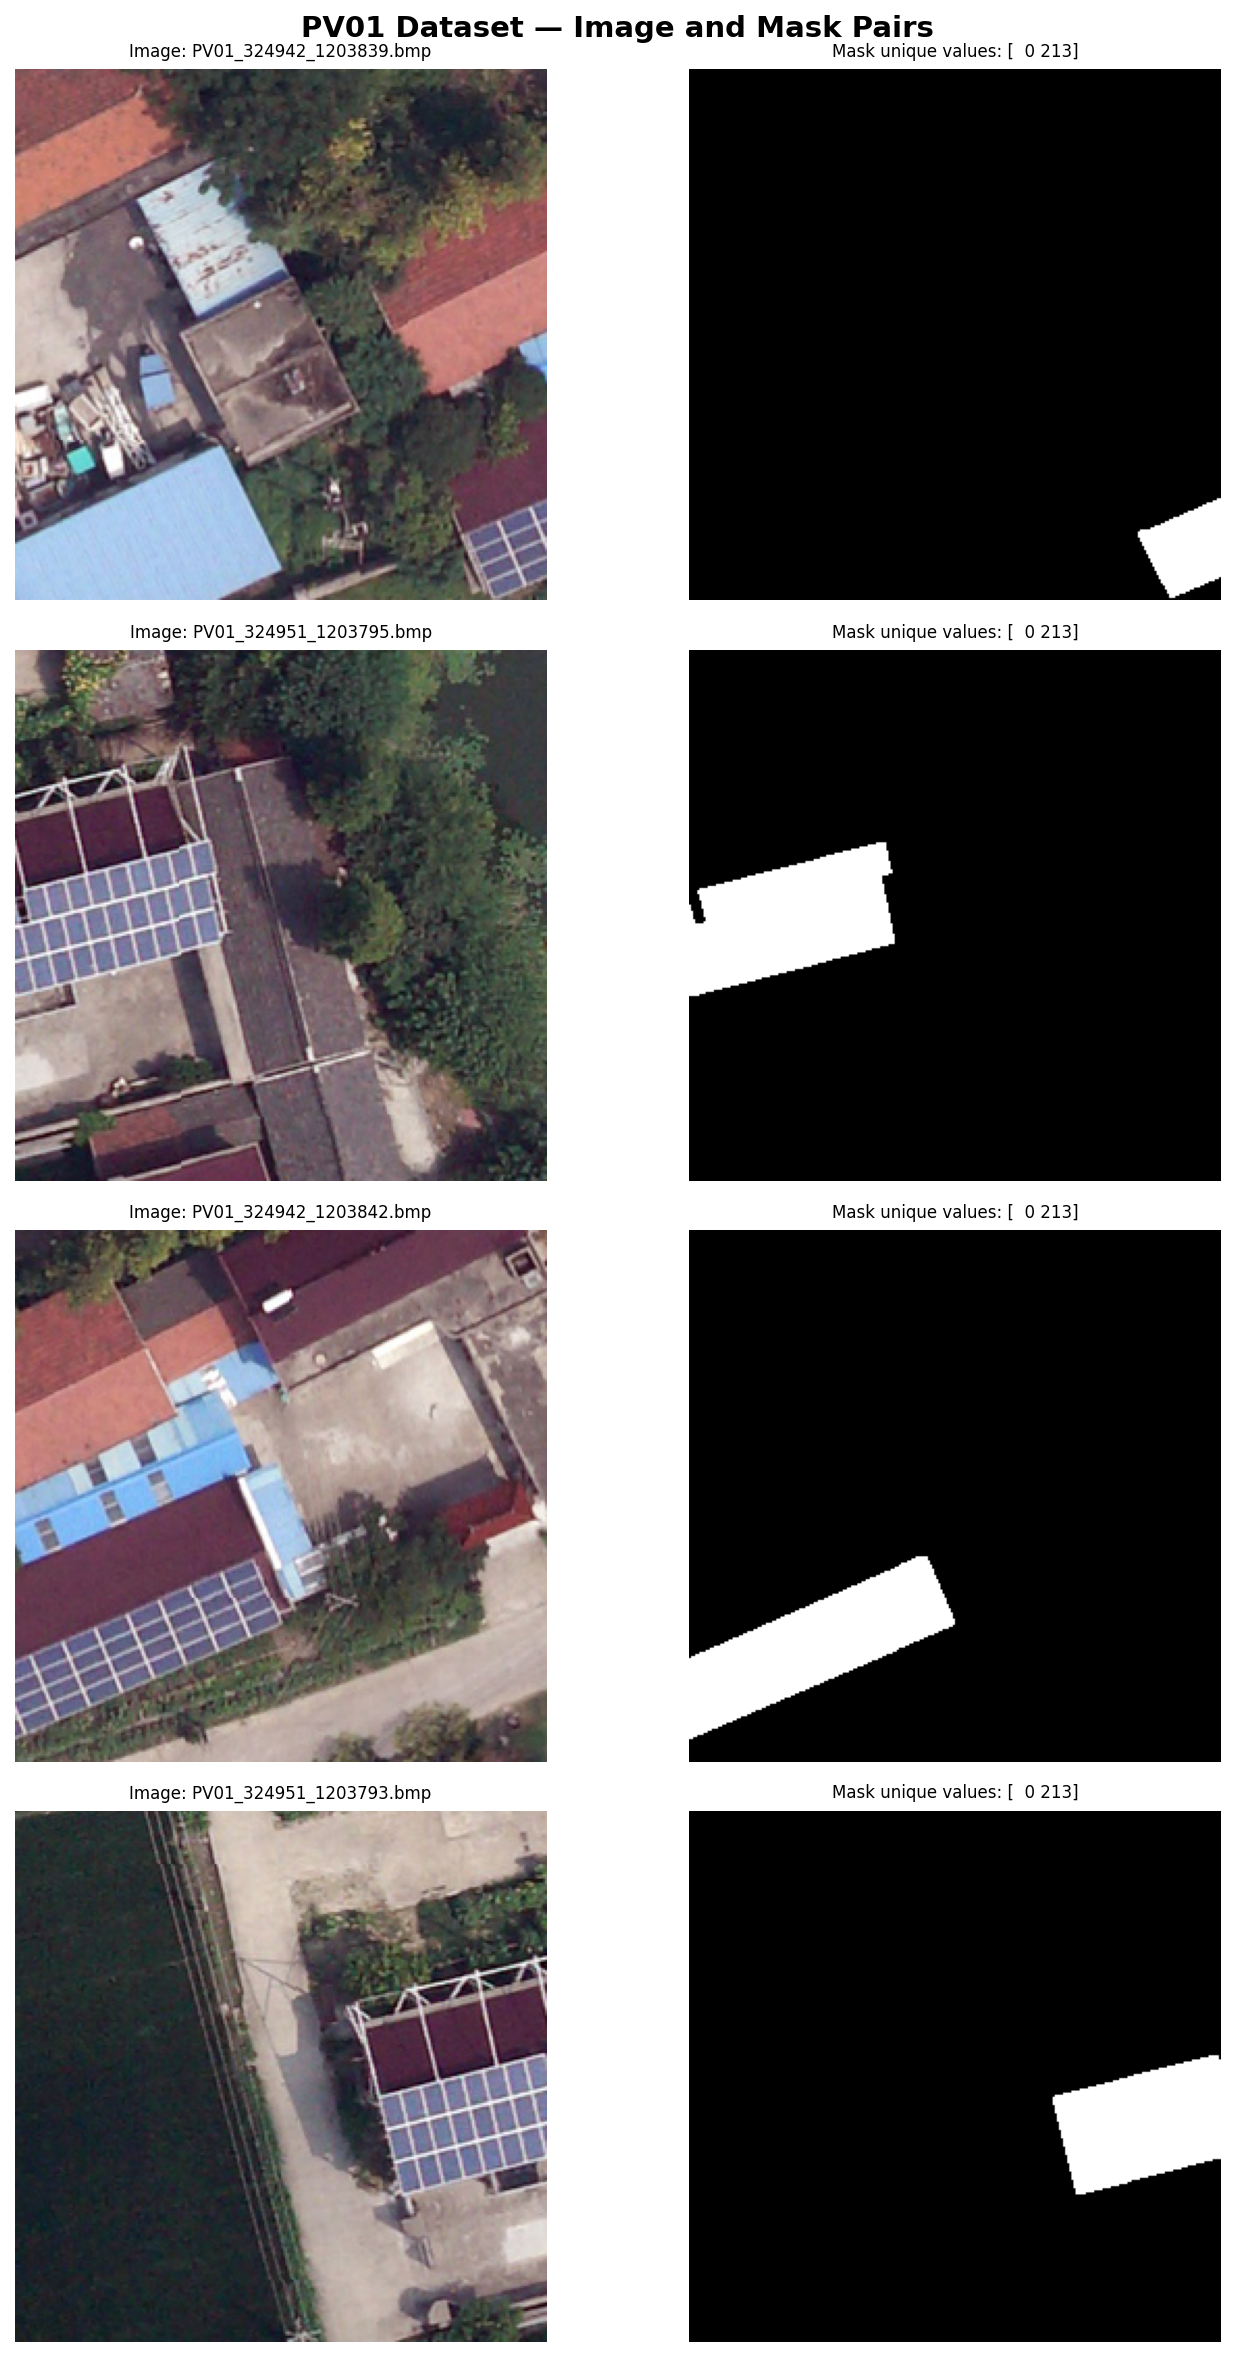

In [126]:
%matplotlib inline

from IPython.display import display, Image as DisplayImage

def show_image_mask_pairs(image_paths, mask_paths, n=4, seed=SEED, save_name="step1_image_mask_pairs.png"):
    # Check paths
    if len(image_paths) == 0:
        print("❌ image_paths is empty. No images found.")
        return
    
    if len(mask_paths) == 0:
        print("❌ mask_paths is empty. No masks found.")
        return

    n = min(n, len(image_paths), len(mask_paths))

    rng = random.Random(seed)
    sample_indices = rng.sample(range(n), n)

    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    if n == 1:
        axes = np.array([axes])

    fig.suptitle("PV01 Dataset — Image and Mask Pairs", fontsize=14, fontweight="bold")

    for row, idx in enumerate(sample_indices):
        image = np.array(Image.open(image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(mask_paths[idx]).convert("L"))

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"Image: {Path(image_paths[idx]).name}", fontsize=8)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title(f"Mask unique values: {np.unique(mask)}", fontsize=8)
        axes[row, 1].axis("off")

    plt.tight_layout()

    save_path = RESULTS_DIR / save_name
    plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

    print(f"✅ Saved: {save_path}")

    # Force display saved image in notebook
    display(DisplayImage(filename=str(save_path)))


show_image_mask_pairs(image_paths, mask_paths)

## 5. Convert segmentation masks to bounding boxes

The custom detector and YOLOv5 need bounding boxes, not segmentation masks.  
So each connected white region in the mask becomes one box: `[x_min, y_min, x_max, y_max]`.


In [127]:
def mask_to_boxes(mask_path, min_size=4):
    """Convert a binary segmentation mask into bounding boxes."""
    mask = np.array(Image.open(mask_path).convert("L"))
    binary_mask = (mask > 0).astype(np.uint8)
    labeled_mask, num_regions = ndimage.label(binary_mask)

    boxes = []
    for region_id in range(1, num_regions + 1):
        ys, xs = np.where(labeled_mask == region_id)
        if len(xs) == 0 or len(ys) == 0:
            continue

        x_min, x_max = int(xs.min()), int(xs.max())
        y_min, y_max = int(ys.min()), int(ys.max())

        if (x_max - x_min) >= min_size and (y_max - y_min) >= min_size:
            boxes.append([x_min, y_min, x_max, y_max])

    return boxes


box_counts = [len(mask_to_boxes(mask_path)) for mask_path in mask_paths]
total_boxes = sum(box_counts)
empty_masks = sum(count == 0 for count in box_counts)

print("✅ Bounding box summary")
print(f"Total images          : {len(mask_paths)}")
print(f"Images with boxes     : {len(mask_paths) - empty_masks}")
print(f"Images with no boxes  : {empty_masks}")
print(f"Total bounding boxes  : {total_boxes}")
print(f"Average boxes/image   : {total_boxes / len(mask_paths):.2f}")
print(f"Max boxes in one image: {max(box_counts)}")


✅ Bounding box summary
Total images          : 645
Images with boxes     : 625
Images with no boxes  : 20
Total bounding boxes  : 5014
Average boxes/image   : 7.77
Max boxes in one image: 36


## 6. Visual check after box conversion

This confirms that the generated bounding boxes match the white solar-panel regions in the masks.


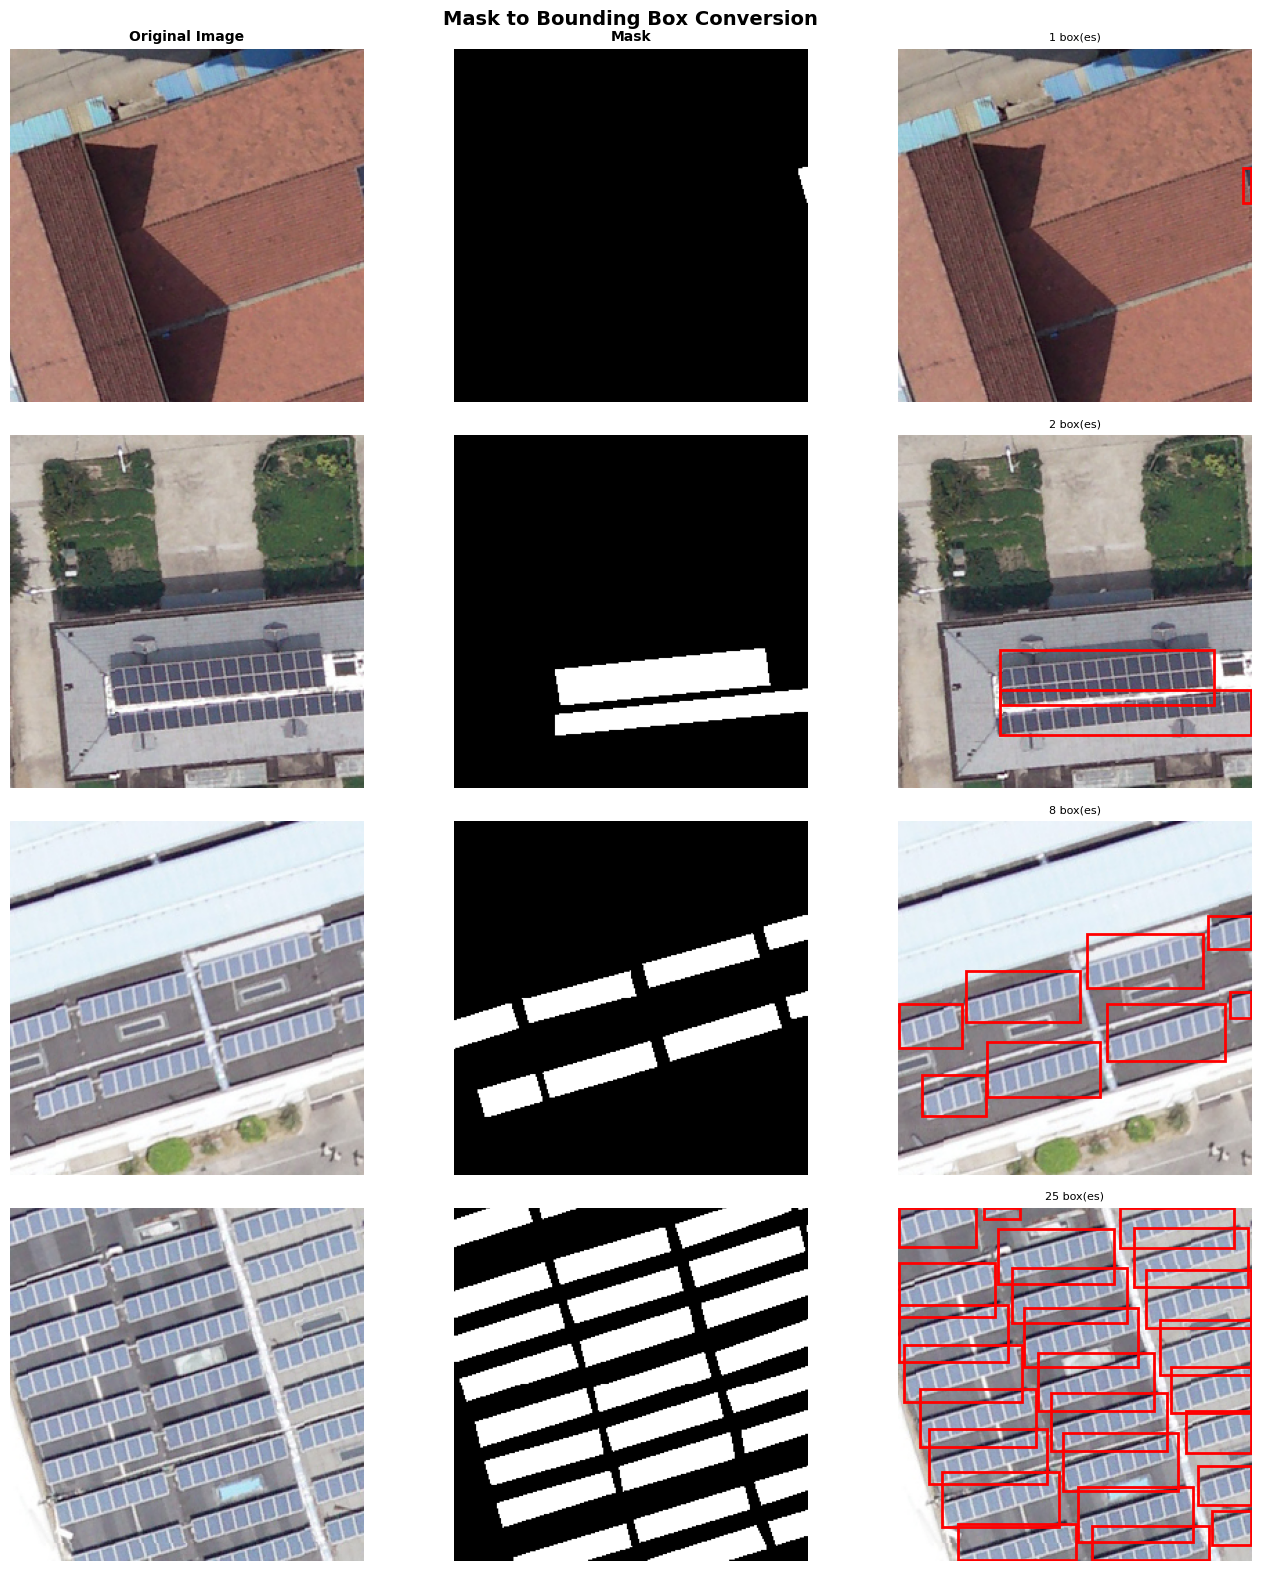

✅ Saved: /kaggle/working/solar_project/results/step2_mask_to_boxes.png


In [128]:
def draw_pixel_boxes(ax, boxes, color="red", linewidth=2):
    for x_min, y_min, x_max, y_max in boxes:
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)


def show_mask_to_box_examples(image_paths, mask_paths, n=4, seed=SEED):
    n = min(n, len(image_paths))
    rng = random.Random(seed)
    sample_indices = rng.sample(range(len(image_paths)), n)

    fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))
    axes = np.atleast_2d(axes)
    fig.suptitle("Mask to Bounding Box Conversion", fontsize=14, fontweight="bold")

    titles = ["Original Image", "Mask", "Image + Boxes"]
    for col, title in enumerate(titles):
        axes[0, col].set_title(title, fontsize=10, fontweight="bold")

    for row, idx in enumerate(sample_indices):
        image = np.array(Image.open(image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(mask_paths[idx]).convert("L"))
        boxes = mask_to_boxes(mask_paths[idx])

        axes[row, 0].imshow(image)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(image)
        draw_pixel_boxes(axes[row, 2], boxes)
        axes[row, 2].set_title(f"{len(boxes)} box(es)", fontsize=8)
        axes[row, 2].axis("off")

    plt.tight_layout()
    save_path = RESULTS_DIR / "step2_mask_to_boxes.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {save_path}")


show_mask_to_box_examples(image_paths, mask_paths)


## 7. Save YOLO-format label files

YOLO labels use normalized values:

```text
class_id center_x center_y width height
```

All coordinates are divided by the image width and height, so the values become between 0 and 1.


In [129]:
def box_to_yolo(box, image_width, image_height):
    """Convert [x_min, y_min, x_max, y_max] to normalized YOLO format."""
    x_min, y_min, x_max, y_max = box
    cx = (x_min + x_max) / 2 / image_width
    cy = (y_min + y_max) / 2 / image_height
    w = (x_max - x_min) / image_width
    h = (y_max - y_min) / image_height
    return cx, cy, w, h


saved_count = 0
skipped_count = 0

for img_path, mask_path in zip(image_paths, mask_paths):
    boxes = mask_to_boxes(mask_path)
    if not boxes:
        skipped_count += 1
        continue

    image_width, image_height = Image.open(img_path).size
    label_path = LABELS_DIR / f"{img_path.stem}.txt"

    with open(label_path, "w") as f:
        for box in boxes:
            cx, cy, w, h = box_to_yolo(box, image_width, image_height)
            f.write(f"{CLASS_ID} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    saved_count += 1

print("✅ Label files saved")
print(f"Saved   : {saved_count}")
print(f"Skipped : {skipped_count} images without boxes")
print(f"Location: {LABELS_DIR}")


✅ Label files saved
Saved   : 625
Skipped : 20 images without boxes
Location: /kaggle/working/solar_project/data/labels


## 8. PyTorch dataset and data loaders

The dataset class:

- loads each image,
- resizes it to `256×256`,
- reads its YOLO label file,
- optionally applies simple data augmentation,
- returns padded boxes so all samples have the same tensor shape.


In [130]:
class SolarPanelDataset(Dataset):
    def __init__(self, image_paths, labels_dir, image_size=IMAGE_SIZE, max_boxes=MAX_BOXES, augment=False):
        self.image_size = image_size
        self.labels_dir = Path(labels_dir)
        self.max_boxes = max_boxes
        self.augment = augment

        self.valid_image_paths = [
            Path(img_path)
            for img_path in image_paths
            if (self.labels_dir / f"{Path(img_path).stem}.txt").exists()
        ]

        print(f"Dataset ready: {len(self.valid_image_paths)} images | augment={augment}")

    def __len__(self):
        return len(self.valid_image_paths)

    def _read_boxes(self, img_path):
        label_path = self.labels_dir / f"{img_path.stem}.txt"
        boxes = []
        with open(label_path, "r") as f:
            for line in f:
                boxes.append([float(value) for value in line.split()])
        return boxes

    def _augment(self, image, boxes):
        # boxes format: [class_id, cx, cy, w, h]
        if random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            boxes = [[b[0], 1.0 - b[1], b[2], b[3], b[4]] for b in boxes]

        if random.random() > 0.5:
            image = image.transpose(Image.FLIP_TOP_BOTTOM)
            boxes = [[b[0], b[1], 1.0 - b[2], b[3], b[4]] for b in boxes]

        if random.random() > 0.5:
            image = ImageEnhance.Brightness(image).enhance(random.uniform(0.7, 1.3))

        if random.random() > 0.5:
            image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))

        return image, boxes

    def __getitem__(self, idx):
        img_path = self.valid_image_paths[idx]
        image = Image.open(img_path).convert("RGB").resize((self.image_size, self.image_size))
        boxes = self._read_boxes(img_path)

        if self.augment:
            image, boxes = self._augment(image, boxes)

        image = np.array(image, dtype=np.float32) / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1)

        padded_boxes = np.zeros((self.max_boxes, 5), dtype=np.float32)
        boxes = np.array(boxes[:self.max_boxes], dtype=np.float32)
        if len(boxes) > 0:
            padded_boxes[:len(boxes)] = boxes

        return image, torch.tensor(padded_boxes), torch.tensor(len(boxes), dtype=torch.long)


## 9. Train/validation split

We use an 80/20 split:

- training set: with augmentation
- validation set: without augmentation


In [131]:
full_dataset = SolarPanelDataset(image_paths, LABELS_DIR, augment=False)

indices = list(range(len(full_dataset)))
random.Random(SEED).shuffle(indices)
split_idx = int(0.8 * len(indices))
train_indices = indices[:split_idx]
val_indices = indices[split_idx:]

train_paths = [full_dataset.valid_image_paths[i] for i in train_indices]
val_paths = [full_dataset.valid_image_paths[i] for i in val_indices]

train_dataset = SolarPanelDataset(train_paths, LABELS_DIR, augment=True)
val_dataset = SolarPanelDataset(val_paths, LABELS_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images_batch, boxes_batch, num_boxes_batch = next(iter(train_loader))

print("\n✅ DataLoaders ready")
print(f"Training samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Image batch shape  : {images_batch.shape}")
print(f"Boxes batch shape  : {boxes_batch.shape}")


Dataset ready: 625 images | augment=False
Dataset ready: 500 images | augment=True
Dataset ready: 125 images | augment=False

✅ DataLoaders ready
Training samples   : 500
Validation samples : 125
Image batch shape  : torch.Size([16, 3, 256, 256])
Boxes batch shape  : torch.Size([16, 36, 5])


## 10. Custom YOLO-style CNN model

The model follows the main YOLO idea:

- divide the image into a grid,
- each grid cell predicts whether it contains an object,
- if it contains an object, it predicts the bounding box.

For a `256×256` image and `16×16` grid, each cell represents a `16×16` pixel area.


In [134]:
import torch.nn as nn


class ConvBlock(nn.Module):
    """Conv2d → BatchNorm2d → ReLU"""
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels,
                              kernel_size=kernel_size, stride=stride,
                              padding=padding, bias=False)
        self.bn   = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class SolarYOLO(nn.Module):
    """
    Custom YOLO-style detector with 16×16 output grid.

    Input : [batch, 3, 256, 256]
    Output: [batch, 16, 16, 5]

    4 MaxPool layers: 256 → 128 → 64 → 32 → 16
    Each cell predicts: [confidence, cx_cell, cy_cell, w, h]
    """
    def __init__(self):
        super().__init__()
        self.grid_size = 16

        self.block1 = nn.Sequential(
            ConvBlock(3,   32), ConvBlock(32,  32),
            nn.MaxPool2d(2, 2)   # 256 → 128
        )
        self.block2 = nn.Sequential(
            ConvBlock(32,  64), ConvBlock(64,  64),
            nn.MaxPool2d(2, 2)   # 128 → 64
        )
        self.block3 = nn.Sequential(
            ConvBlock(64,  128), ConvBlock(128, 128),
            nn.MaxPool2d(2, 2)   # 64 → 32
        )
        self.block4 = nn.Sequential(
            ConvBlock(128, 256), ConvBlock(256, 256),
            nn.MaxPool2d(2, 2)   # 32 → 16  ← STOPS HERE
        )

        # Detection head — no Dropout (hurts confidence at inference)
        self.detection_head = nn.Sequential(
            ConvBlock(256, 256),
            nn.Conv2d(256, 5, kernel_size=1)
        )

        # Bias = +2.0 → sigmoid(2.0) ≈ 0.88 starting confidence
        # Prevents the model from learning to predict zero everywhere
        nn.init.constant_(self.detection_head[-1].bias[0], 2.0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.detection_head(x)
        x = x.permute(0, 2, 3, 1)          # [B,5,16,16] → [B,16,16,5]

        confidence = torch.sigmoid(x[..., 0:1])
        cx         = torch.sigmoid(x[..., 1:2])
        cy         = torch.sigmoid(x[..., 2:3])
        w          = torch.sigmoid(x[..., 3:4])
        h          = torch.sigmoid(x[..., 4:5])

        return torch.cat([confidence, cx, cy, w, h], dim=-1)


# Verify architecture
model        = SolarYOLO().to(device)
dummy        = torch.zeros(2, 3, 256, 256).to(device)
out          = model(dummy)
init_conf    = out[0, :, :, 0]
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ SolarYOLO ready")
print(f"   Input shape         : {dummy.shape}")
print(f"   Output shape        : {out.shape}  ← must be [2, 16, 16, 5]")
print(f"   Init conf mean      : {init_conf.mean():.3f}  ← should be ~0.88")
print(f"   Trainable params    : {total_params:,}")

✅ SolarYOLO ready
   Input shape         : torch.Size([2, 3, 256, 256])
   Output shape        : torch.Size([2, 16, 16, 5])  ← must be [2, 16, 16, 5]
   Init conf mean      : 0.881  ← should be ~0.88
   Trainable params    : 1,764,837


## 11. Target grid and loss function

The target grid has shape `[batch, 16, 16, 5]`.

For each object:

- `confidence = 1` in the responsible cell,
- center coordinates are stored relative to that cell,
- width and height stay normalized to the whole image.

The loss combines:

- object confidence loss,
- no-object confidence loss,
- bounding box regression loss.


In [135]:
def build_target_grid(boxes_batch, num_boxes_batch, grid_size=GRID_SIZE):
    """Build YOLO-style target grids from normalized boxes."""
    batch_size = boxes_batch.shape[0]
    target = torch.zeros(batch_size, grid_size, grid_size, 5, device=boxes_batch.device)

    for b in range(batch_size):
        for i in range(int(num_boxes_batch[b].item())):
            _, cx, cy, w, h = boxes_batch[b, i]
            col = min(int(cx.item() * grid_size), grid_size - 1)
            row = min(int(cy.item() * grid_size), grid_size - 1)

            # One box per cell in this simple custom YOLO version.
            if target[b, row, col, 0] == 0:
                target[b, row, col, 0] = 1.0
                target[b, row, col, 1] = cx * grid_size - col
                target[b, row, col, 2] = cy * grid_size - row
                target[b, row, col, 3] = w
                target[b, row, col, 4] = h

    return target


def yolo_loss(predictions, targets, lambda_box=5.0, lambda_obj=5.0, lambda_noobj=0.1):
    """YOLO-style loss: BCE confidence + Smooth L1 box regression."""
    obj_mask = targets[..., 0] == 1
    noobj_mask = ~obj_mask

    obj_loss = nn.functional.binary_cross_entropy(
        predictions[..., 0][obj_mask],
        targets[..., 0][obj_mask],
        reduction="sum"
    ) if obj_mask.any() else torch.tensor(0.0, device=predictions.device)

    noobj_loss = nn.functional.binary_cross_entropy(
        predictions[..., 0][noobj_mask],
        targets[..., 0][noobj_mask],
        reduction="sum"
    )

    box_loss = nn.functional.smooth_l1_loss(
        predictions[..., 1:][obj_mask],
        targets[..., 1:][obj_mask],
        reduction="sum"
    ) if obj_mask.any() else torch.tensor(0.0, device=predictions.device)

    total = lambda_box * box_loss + lambda_obj * obj_loss + lambda_noobj * noobj_loss
    return total, obj_loss, noobj_loss, box_loss


sample_target = build_target_grid(boxes_batch[:2].to(DEVICE), num_boxes_batch[:2].to(DEVICE))
object_cells = sample_target[sample_target[..., 0] == 1]

print("✅ Target grid and loss are ready")
print(f"Target shape       : {sample_target.shape}")
print(f"Cells with objects : {(sample_target[..., 0] == 1).sum().item()}")
if len(object_cells) > 0:
    print(f"cx_cell range      : {object_cells[:, 1].min():.3f} to {object_cells[:, 1].max():.3f}")
    print(f"cy_cell range      : {object_cells[:, 2].min():.3f} to {object_cells[:, 2].max():.3f}")


✅ Target grid and loss are ready
Target shape       : torch.Size([2, 16, 16, 5])
Cells with objects : 3
cx_cell range      : 0.188 to 0.750
cy_cell range      : 0.250 to 0.500


## 12. Train with early stopping

Early stopping saves the best model whenever validation loss improves.  
If validation loss does not improve for several epochs, training stops automatically.


In [136]:
def run_one_epoch(model, loader, optimizer=None):
    """Run one training or validation epoch."""
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_obj = 0.0
    total_box = 0.0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, boxes, num_boxes in loader:
            images = images.to(DEVICE)
            boxes = boxes.to(DEVICE)
            num_boxes = num_boxes.to(DEVICE)
            targets = build_target_grid(boxes, num_boxes)

            predictions = model(images)
            loss, obj_loss, _, box_loss = yolo_loss(predictions, targets)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item()
            total_obj += obj_loss.item()
            total_box += box_loss.item()

    n_batches = len(loader)
    return total_loss / n_batches, total_obj / n_batches, total_box / n_batches


model = SolarYOLO().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=8)

NUM_EPOCHS = 80
EARLY_STOP_PATIENCE = 10
MIN_DELTA = 1e-4
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_model.pth"

best_val_loss = float("inf")
patience_counter = 0
train_losses, val_losses = [], []

print("Starting training with Early Stopping...\n")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Obj Loss':<12} {'Box Loss':<12} {'LR':<12} {'Patience'}")
print("-" * 95)

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss, obj_loss, box_loss = run_one_epoch(model, train_loader, optimizer)
    val_loss, _, _ = run_one_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    improved = val_loss < best_val_loss - MIN_DELTA
    if improved:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        marker = "⭐ best saved"
    else:
        patience_counter += 1
        marker = ""

    print(f"{epoch:<8} {train_loss:<14.2f} {val_loss:<14.2f} {obj_loss:<12.2f} {box_loss:<12.2f} {current_lr:<12.6f} {patience_counter}/{EARLY_STOP_PATIENCE} {marker}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch}.")
        break

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

print("\n✅ Training complete")
print(f"Epochs completed : {len(train_losses)}/{NUM_EPOCHS}")
print(f"Best val loss    : {best_val_loss:.2f}")
print(f"Best model saved : {BEST_MODEL_PATH}")


Starting training with Early Stopping...

Epoch    Train Loss     Val Loss       Obj Loss     Box Loss     LR           Patience
-----------------------------------------------------------------------------------------------
1        677.52         535.10         23.68        14.57        0.000500     0/10 ⭐ best saved
2        462.28         444.16         30.04        10.24        0.000500     0/10 ⭐ best saved
3        405.18         373.57         29.03        9.00         0.000500     0/10 ⭐ best saved
4        371.99         342.83         28.90        8.26         0.000500     0/10 ⭐ best saved
5        330.31         280.52         26.11        7.31         0.000500     0/10 ⭐ best saved
6        289.09         277.68         22.00        6.58         0.000500     0/10 ⭐ best saved
7        267.34         254.79         20.32        6.15         0.000500     0/10 ⭐ best saved
8        244.79         257.94         18.68        5.84         0.000500     1/10 
9        235.65    

## 13. Plot training curves

The best sign is when training loss and validation loss both decrease. If validation loss starts increasing while training loss decreases, that means overfitting.


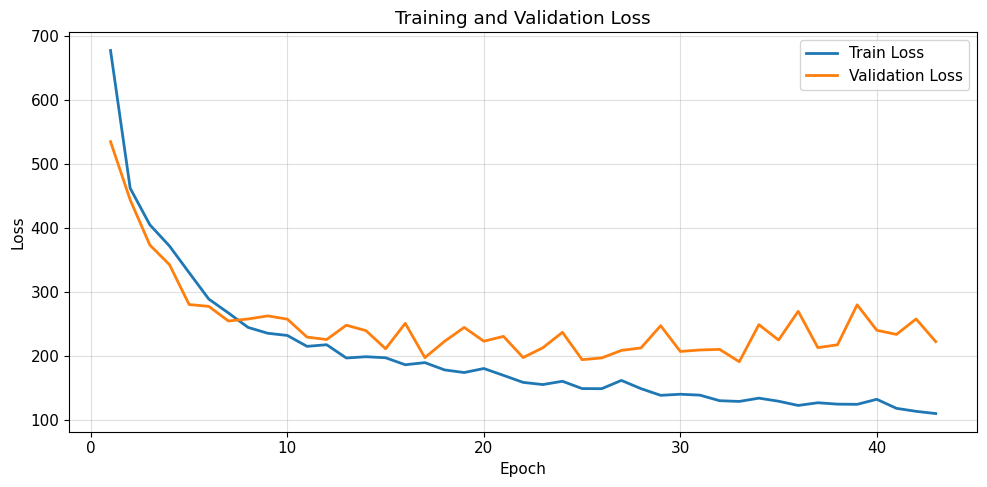

✅ Saved: /kaggle/working/solar_project/results/loss_curve.png


In [137]:
epoch_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_range, train_losses, label="Train Loss", linewidth=2)
plt.plot(epoch_range, val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

save_path = RESULTS_DIR / "loss_curve.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")


## 14. Evaluation helpers

The model output must be decoded back into bounding boxes. Then we apply Non-Maximum Suppression (NMS) to remove duplicate overlapping predictions.

Metrics:

- **TP:** predicted box matches a real box
- **FP:** predicted box does not match a real box
- **FN:** real box missed by the model
- **F1:** balances Precision and Recall


In [138]:
def predictions_to_boxes(prediction, conf_threshold=0.5, grid_size=GRID_SIZE):
    """Convert model grid output to normalized boxes: [conf, cx, cy, w, h]."""
    boxes = []
    for row in range(grid_size):
        for col in range(grid_size):
            conf, cx_cell, cy_cell, w, h = prediction[row, col].tolist()
            if conf >= conf_threshold:
                cx = (cx_cell + col) / grid_size
                cy = (cy_cell + row) / grid_size
                boxes.append([conf, cx, cy, w, h])
    return boxes


def compute_iou(box1, box2):
    """IoU between two boxes in [cx, cy, w, h] format."""
    def to_xyxy(box):
        cx, cy, w, h = box
        return [cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2]

    x1_min, y1_min, x1_max, y1_max = to_xyxy(box1)
    x2_min, y2_min, x2_max, y2_max = to_xyxy(box2)

    inter_w = max(0, min(x1_max, x2_max) - max(x1_min, x2_min))
    inter_h = max(0, min(y1_max, y2_max) - max(y1_min, y2_min))
    inter_area = inter_w * inter_h

    area1 = max(0, x1_max - x1_min) * max(0, y1_max - y1_min)
    area2 = max(0, x2_max - x2_min) * max(0, y2_max - y2_min)
    union = area1 + area2 - inter_area + 1e-6
    return inter_area / union


def nms(boxes, iou_threshold=0.1):
    """Keep high-confidence boxes and remove duplicate overlaps."""
    boxes = sorted(boxes, key=lambda x: x[0], reverse=True)
    kept = []

    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [box for box in boxes if compute_iou(best[1:], box[1:]) < iou_threshold]

    return kept


def evaluate_detector(model, dataset, conf_threshold=0.5, iou_threshold=0.1):
    """Evaluate detector on a dataset."""
    model.eval()
    tp = fp = fn = 0

    with torch.no_grad():
        for image, boxes_tensor, num_boxes in dataset:
            prediction = model(image.unsqueeze(0).to(DEVICE))[0].cpu()
            pred_boxes = nms(predictions_to_boxes(prediction, conf_threshold), iou_threshold)

            gt_boxes = [
                boxes_tensor[i][1:].tolist()
                for i in range(int(num_boxes.item()))
            ]

            matched_gt = set()
            for pred_box in pred_boxes:
                best_iou = 0
                best_gt_idx = -1

                for gt_idx, gt_box in enumerate(gt_boxes):
                    iou = compute_iou(pred_box[1:], gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx

                if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
                    tp += 1
                    matched_gt.add(best_gt_idx)
                else:
                    fp += 1

            fn += len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return {"TP": tp, "FP": fp, "FN": fn, "Precision": precision, "Recall": recall, "F1": f1}


print("✅ Evaluation functions ready")


✅ Evaluation functions ready


## 15. Search for the best confidence threshold

A lower threshold usually increases Recall but may create more False Positives.  
A higher threshold usually increases Precision but may miss more panels.

We choose the threshold that gives the best F1 score.


In [139]:
thresholds = [0.2, 0.3, 0.4, 0.5]
rows = []

for threshold in thresholds:
    metrics = evaluate_detector(model, val_dataset, conf_threshold=threshold, iou_threshold=0.1)
    rows.append({"Threshold": threshold, **metrics})

results_df = pd.DataFrame(rows)
best_row = results_df.loc[results_df["F1"].idxmax()]
best_thresh = float(best_row["Threshold"])
best_m = best_row.to_dict()

display(results_df.round(4))

print("✅ Best threshold result")
print(f"Threshold : {best_thresh}")
print(f"Precision : {best_m['Precision']:.4f}")
print(f"Recall    : {best_m['Recall']:.4f}")
print(f"F1 Score  : {best_m['F1']:.4f}")


,Threshold,TP,FP,FN,Precision,Recall,F1
0,0.2,850,154,71,0.8466,0.9229,0.8831
1,0.3,842,131,79,0.8654,0.9142,0.8891
2,0.4,836,108,85,0.8856,0.9077,0.8965
3,0.5,829,92,92,0.9001,0.9001,0.9001


✅ Best threshold result
Threshold : 0.5
Precision : 0.9001
Recall    : 0.9001
F1 Score  : 0.9001


## 16. Final custom model plots

These plots are useful for the final report/discussion:

1. bar chart for Precision, Recall, F1,
2. threshold comparison chart,
3. qualitative predictions.


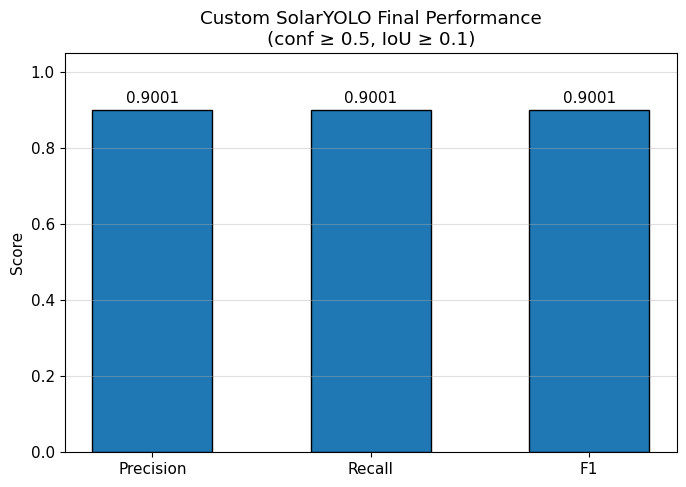

✅ Saved: /kaggle/working/solar_project/results/final_bar_chart.png


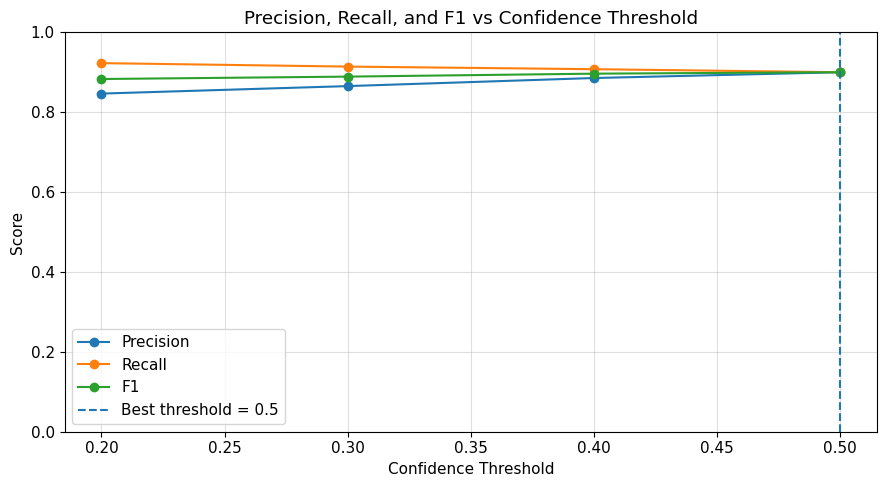

✅ Saved: /kaggle/working/solar_project/results/threshold_comparison.png


In [140]:
# Final metrics bar chart
metric_names = ["Precision", "Recall", "F1"]
metric_values = [best_m[name] for name in metric_names]

plt.figure(figsize=(7, 5))
bars = plt.bar(metric_names, metric_values, edgecolor="black", width=0.55)
for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.4f}", ha="center", va="bottom")

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title(f"Custom SolarYOLO Final Performance\n(conf ≥ {best_thresh}, IoU ≥ 0.1)")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
save_path = RESULTS_DIR / "final_bar_chart.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")

# Threshold comparison
plt.figure(figsize=(9, 5))
for metric in ["Precision", "Recall", "F1"]:
    plt.plot(results_df["Threshold"], results_df[metric], marker="o", label=metric)
plt.axvline(best_thresh, linestyle="--", label=f"Best threshold = {best_thresh}")
plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Confidence Threshold")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
save_path = RESULTS_DIR / "threshold_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")


## 17. Qualitative custom model predictions

Green boxes are ground truth. Blue boxes are model predictions.


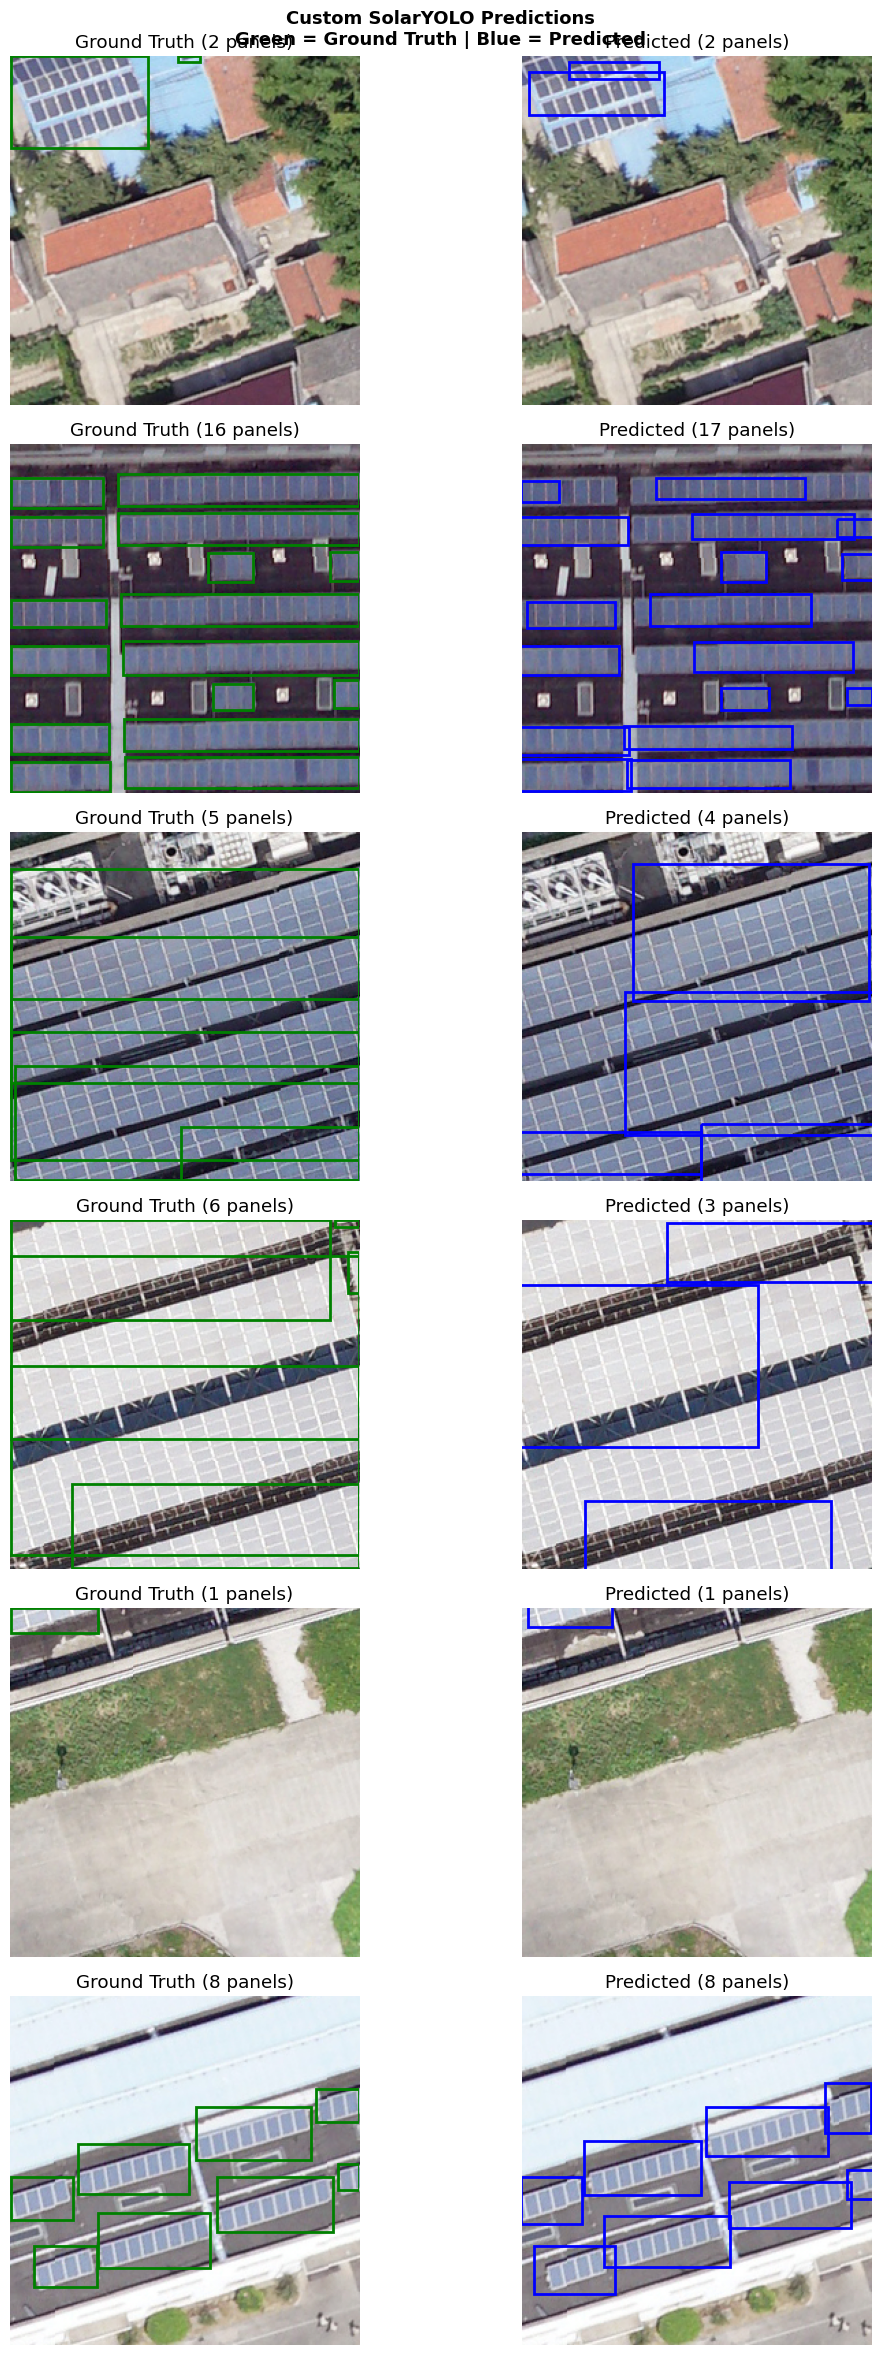

✅ Saved: /kaggle/working/solar_project/results/final_qualitative.png


In [141]:
def draw_normalized_boxes(ax, boxes, img_w, img_h, color, label=None):
    for box in boxes:
        cx, cy, w, h = box
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        rect = patches.Rectangle(
            (x1, y1),
            w * img_w,
            h * img_h,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)


def show_custom_predictions(model, dataset, n=6, seed=SEED):
    n = min(n, len(dataset))
    rng = random.Random(seed)
    sample_indices = rng.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    fig.suptitle("Custom SolarYOLO Predictions\nGreen = Ground Truth | Blue = Predicted", fontsize=13, fontweight="bold")

    model.eval()
    for row, idx in enumerate(sample_indices):
        image, boxes_tensor, num_boxes = dataset[idx]
        img_np = image.permute(1, 2, 0).numpy()
        img_h, img_w = img_np.shape[:2]

        gt_boxes = [boxes_tensor[i][1:].tolist() for i in range(int(num_boxes.item()))]

        with torch.no_grad():
            prediction = model(image.unsqueeze(0).to(DEVICE))[0].cpu()
        pred_boxes = nms(predictions_to_boxes(prediction, best_thresh), iou_threshold=0.1)
        pred_boxes = [box[1:] for box in pred_boxes]

        axes[row, 0].imshow(img_np)
        draw_normalized_boxes(axes[row, 0], gt_boxes, img_w, img_h, color="green")
        axes[row, 0].set_title(f"Ground Truth ({len(gt_boxes)} panels)")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_np)
        draw_normalized_boxes(axes[row, 1], pred_boxes, img_w, img_h, color="blue")
        axes[row, 1].set_title(f"Predicted ({len(pred_boxes)} panels)")
        axes[row, 1].axis("off")

    plt.tight_layout()
    save_path = RESULTS_DIR / "final_qualitative.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {save_path}")


show_custom_predictions(model, val_dataset)


## 18. Save custom model evaluation table

This table can be added directly to the report.


In [142]:
custom_results_path = RESULTS_DIR / "evaluation_results.csv"
results_df.round(4).to_csv(custom_results_path, index=False)

print(f"✅ Saved: {custom_results_path}")
display(results_df.round(4))

print("\nFinal best custom model result:")
print(f"Threshold : {best_thresh}")
print(f"Precision : {best_m['Precision']:.4f}")
print(f"Recall    : {best_m['Recall']:.4f}")
print(f"F1 Score  : {best_m['F1']:.4f}")
print(f"TP / FP / FN: {int(best_m['TP'])} / {int(best_m['FP'])} / {int(best_m['FN'])}")


✅ Saved: /kaggle/working/solar_project/results/evaluation_results.csv


,Threshold,TP,FP,FN,Precision,Recall,F1
0,0.2,850,154,71,0.8466,0.9229,0.8831
1,0.3,842,131,79,0.8654,0.9142,0.8891
2,0.4,836,108,85,0.8856,0.9077,0.8965
3,0.5,829,92,92,0.9001,0.9001,0.9001



Final best custom model result:
Threshold : 0.5
Precision : 0.9001
Recall    : 0.9001
F1 Score  : 0.9001
TP / FP / FN: 829 / 92 / 92


# Part 2 — YOLOv5 using pretrained weights

This part uses **transfer learning**. YOLOv5s starts from pretrained weights, then fine-tunes on our solar-panel dataset.

For discussion:

- The custom model learns from zero.
- YOLOv5s already learned useful visual features from a large dataset.
- That is why pretrained YOLOv5 usually gives better results with less training.


## 19. Prepare YOLOv5 dataset folders

YOLOv5 expects this folder structure:

```text
yolov5_dataset/
├── images/train
├── images/val
├── labels/train
└── labels/val
```


In [143]:
YOLO_DATASET_DIR = PROJECT_DIR / "yolov5_dataset"

for split_name in ["train", "val"]:
    (YOLO_DATASET_DIR / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_DIR / "labels" / split_name).mkdir(parents=True, exist_ok=True)


def copy_yolov5_split(dataset, split_name):
    copied_images = 0
    copied_labels = 0

    for img_path in dataset.valid_image_paths:
        img_path = Path(img_path)
        label_path = LABELS_DIR / f"{img_path.stem}.txt"

        dst_img = YOLO_DATASET_DIR / "images" / split_name / img_path.name
        dst_lbl = YOLO_DATASET_DIR / "labels" / split_name / label_path.name

        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)
            copied_images += 1

        if label_path.exists() and not dst_lbl.exists():
            shutil.copy2(label_path, dst_lbl)
            copied_labels += 1

    print(f"{split_name}: copied {copied_images} images and {copied_labels} labels")


copy_yolov5_split(train_dataset, "train")
copy_yolov5_split(val_dataset, "val")

YOLO_DATA_YAML = YOLO_DATASET_DIR / "solar_panel.yaml"
yolo_data_config = {
    "path": str(YOLO_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "nc": 1,
    "names": [CLASS_NAME]
}

with open(YOLO_DATA_YAML, "w") as f:
    yaml.safe_dump(yolo_data_config, f, sort_keys=False)

print("✅ YOLOv5 dataset prepared")
print(f"YAML path: {YOLO_DATA_YAML}")
print(yaml.safe_dump(yolo_data_config, sort_keys=False))


train: copied 0 images and 0 labels
val: copied 0 images and 0 labels
✅ YOLOv5 dataset prepared
YAML path: /kaggle/working/solar_project/yolov5_dataset/solar_panel.yaml
path: /kaggle/working/solar_project/yolov5_dataset
train: images/train
val: images/val
nc: 1
names:
- solar_panel



## 20. Download YOLOv5 and install requirements

This cell clones YOLOv5 only if it is not already downloaded.


In [144]:
YOLOV5_DIR = WORKING_DIR / "yolov5"

if not YOLOV5_DIR.exists():
    print("Cloning YOLOv5 repository...")
    subprocess.run(["git", "clone", "https://github.com/ultralytics/yolov5", str(YOLOV5_DIR)], check=True)
else:
    print("✅ YOLOv5 repository already exists")

print("Installing YOLOv5 requirements...")
subprocess.run([sys.executable, "-m", "pip", "install", "-qr", str(YOLOV5_DIR / "requirements.txt")], check=True)
print("✅ YOLOv5 is ready")


✅ YOLOv5 repository already exists
Installing YOLOv5 requirements...
✅ YOLOv5 is ready


## 21. Train YOLOv5s with pretrained weights

This trains YOLOv5s using `yolov5s.pt` pretrained weights.


In [146]:
YOLOV5_EPOCHS = 20
YOLOV5_BATCH_SIZE = 16
YOLOV5_IMG_SIZE = IMAGE_SIZE
YOLOV5_PATIENCE = 5

YOLO_RUNS_DIR = PROJECT_DIR / "yolov5_runs"
YOLO_RUN_NAME = "yolov5s_pretrained_solar"

train_cmd = [
    sys.executable, str(YOLOV5_DIR / "train.py"),
    "--img", str(YOLOV5_IMG_SIZE),
    "--batch", str(YOLOV5_BATCH_SIZE),
    "--epochs", str(YOLOV5_EPOCHS),
    "--data", str(YOLO_DATA_YAML),
    "--cfg", str(YOLOV5_DIR / "models" / "yolov5s.yaml"),
    "--weights", "yolov5s.pt",
    "--project", str(YOLO_RUNS_DIR),
    "--name", YOLO_RUN_NAME,
    "--patience", str(YOLOV5_PATIENCE),
    "--exist-ok"
]

print("Training command:")
print(" ".join(map(str, train_cmd)))

subprocess.run(train_cmd, check=True)

YOLOV5_BEST_WEIGHTS = YOLO_RUNS_DIR / YOLO_RUN_NAME / "weights" / "best.pt"
print("✅ YOLOv5 training finished")
print(f"Best weights: {YOLOV5_BEST_WEIGHTS}")


Training command:
/usr/bin/python3 /kaggle/working/yolov5/train.py --img 256 --batch 16 --epochs 20 --data /kaggle/working/solar_project/yolov5_dataset/solar_panel.yaml --cfg /kaggle/working/yolov5/models/yolov5s.yaml --weights yolov5s.pt --project /kaggle/working/solar_project/yolov5_runs --name yolov5s_pretrained_solar --patience 5 --exist-ok


wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-05-08 13:01:15.174585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778245275.197581    2251 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778245275.205215    2251 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778245275.224669    2251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778245275.224694    2251 computation_placer.cc:177] computation placer already registere

✅ YOLOv5 training finished
Best weights: /kaggle/working/solar_project/yolov5_runs/yolov5s_pretrained_solar/weights/best.pt


## 22. Read YOLOv5 results

YOLOv5 saves metrics in `results.csv`. We select the epoch with the best `mAP@0.5` and calculate F1 from Precision and Recall.


In [147]:
YOLO_RESULTS_CSV = YOLO_RUNS_DIR / YOLO_RUN_NAME / "results.csv"

yolo_results_df = pd.read_csv(YOLO_RESULTS_CSV)
yolo_results_df.columns = yolo_results_df.columns.str.strip()


def find_metric_column(possible_names):
    for name in possible_names:
        if name in yolo_results_df.columns:
            return name
    raise ValueError(f"Could not find any of these columns: {possible_names}")


precision_col = find_metric_column(["metrics/precision", "metrics/precision(B)"])
recall_col = find_metric_column(["metrics/recall", "metrics/recall(B)"])
map50_col = find_metric_column(["metrics/mAP_0.5", "metrics/mAP50(B)"])

best_yolo_row = yolo_results_df.loc[yolo_results_df[map50_col].idxmax()]
yolo_precision = float(best_yolo_row[precision_col])
yolo_recall = float(best_yolo_row[recall_col])
yolo_f1 = 2 * yolo_precision * yolo_recall / (yolo_precision + yolo_recall + 1e-9)
yolo_map50 = float(best_yolo_row[map50_col])

yolov5_summary_df = pd.DataFrame([{
    "Model": "YOLOv5s",
    "Training Type": "Pretrained YOLOv5s weights + fine-tuning",
    "Pretrained Weights Used": "Yes",
    "Best Epoch": int(best_yolo_row["epoch"]) if "epoch" in yolo_results_df.columns else "N/A",
    "Precision": round(yolo_precision, 4),
    "Recall": round(yolo_recall, 4),
    "F1": round(yolo_f1, 4),
    "mAP@0.5": round(yolo_map50, 4)
}])

display(yolov5_summary_df)


,Model,Training Type,Pretrained Weights Used,Best Epoch,Precision,Recall,F1,mAP@0.5
0,YOLOv5s,Pretrained YOLOv5s weights + fine-tuning,Yes,29,0.9702,0.9181,0.9434,0.9699


## 23. Compare custom model vs pretrained YOLOv5s

This comparison is useful for the final discussion because it clearly shows the effect of transfer learning.


In [148]:
comparison_df = pd.DataFrame([
    {
        "Model": "Custom SolarYOLO",
        "Training Type": "Custom architecture trained from scratch",
        "Pretrained Weights Used": "No",
        "Best Threshold": best_thresh,
        "Precision": round(best_m["Precision"], 4),
        "Recall": round(best_m["Recall"], 4),
        "F1": round(best_m["F1"], 4),
        "mAP@0.5": "Not calculated"
    },
    {
        "Model": "YOLOv5s",
        "Training Type": "Pretrained YOLOv5s weights + fine-tuning",
        "Pretrained Weights Used": "Yes",
        "Best Threshold": "YOLOv5 validation default",
        "Precision": round(yolo_precision, 4),
        "Recall": round(yolo_recall, 4),
        "F1": round(yolo_f1, 4),
        "mAP@0.5": round(yolo_map50, 4)
    }
])

comparison_path = RESULTS_DIR / "custom_vs_yolov5_pretrained_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)
print(f"✅ Saved: {comparison_path}")


,Model,Training Type,Pretrained Weights Used,Best Threshold,Precision,Recall,F1,mAP@0.5
0,Custom SolarYOLO,Custom architecture trained from scratch,No,0.5,0.9001,0.9001,0.9001,Not calculated
1,YOLOv5s,Pretrained YOLOv5s weights + fine-tuning,Yes,YOLOv5 validation default,0.9702,0.9181,0.9434,0.9699


✅ Saved: /kaggle/working/solar_project/results/custom_vs_yolov5_pretrained_comparison.csv


## 24. Plot model comparison

Higher Precision, Recall, and F1 are better.


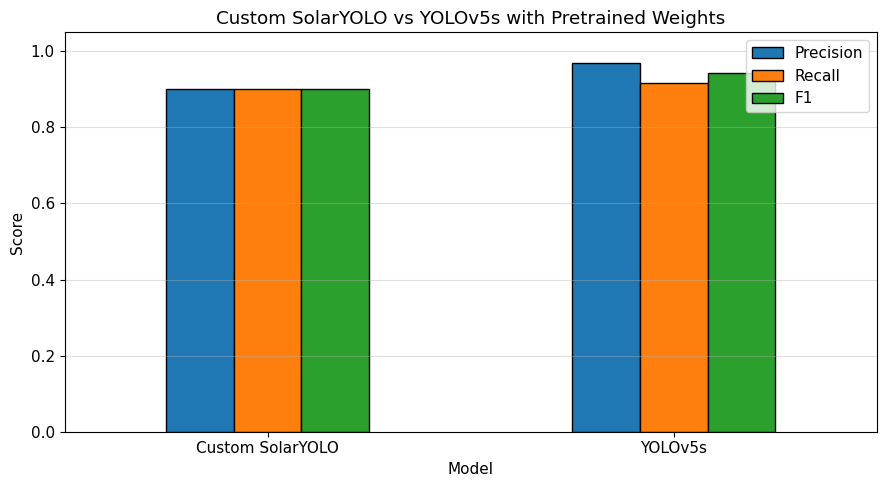

✅ Saved: /kaggle/working/solar_project/results/custom_vs_yolov5_pretrained_bar_chart.png


In [149]:
plot_df = comparison_df.set_index("Model")[["Precision", "Recall", "F1"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5), edgecolor="black")
plt.title("Custom SolarYOLO vs YOLOv5s with Pretrained Weights")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.4)
plt.legend(loc="upper right")
plt.tight_layout()

save_path = RESULTS_DIR / "custom_vs_yolov5_pretrained_bar_chart.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")


## 25. Visualize YOLOv5 predictions

This final qualitative check shows YOLOv5 predictions on validation images.


YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/kaggle/working/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


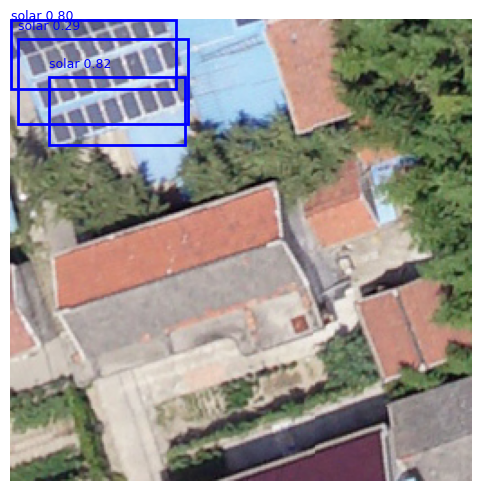

/kaggle/working/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


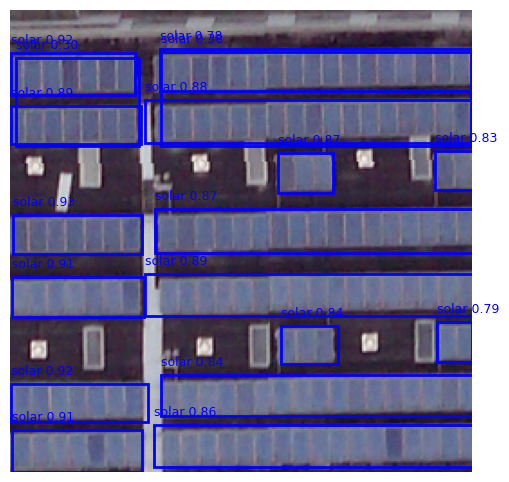

/kaggle/working/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


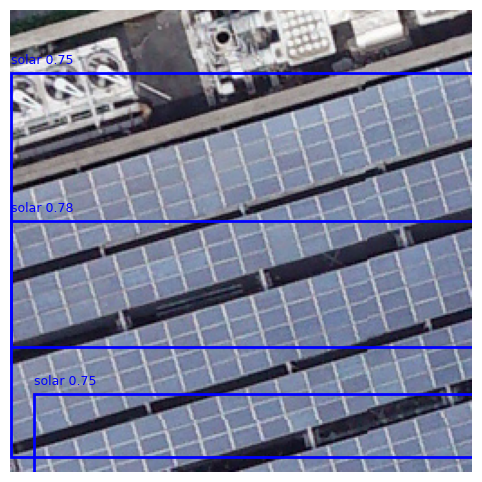

/kaggle/working/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


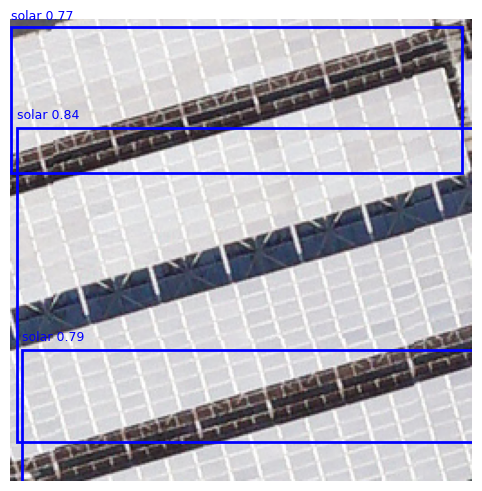

In [151]:
trained_yolov5_model = torch.hub.load(
    str(YOLOV5_DIR),
    "custom",
    path=str(YOLOV5_BEST_WEIGHTS),
    source="local"
)

trained_yolov5_model.to(DEVICE)
trained_yolov5_model.eval()
trained_yolov5_model.conf = 0.25

sample_indices = random.Random(SEED).sample(
    range(len(val_dataset)),
    min(4, len(val_dataset))
)

for idx in sample_indices:
    image_path = val_dataset.valid_image_paths[idx]
    image = Image.open(image_path).convert("RGB")

    results = trained_yolov5_model(str(image_path), size=YOLOV5_IMG_SIZE)
    pred_df = results.pandas().xyxy[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image)
    ax.axis("off")

    for _, row in pred_df.iterrows():
        x1, y1 = float(row["xmin"]), float(row["ymin"])
        x2, y2 = float(row["xmax"]), float(row["ymax"])
        conf = float(row["confidence"])

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="blue",
            facecolor="none"
        )

        ax.add_patch(rect)
        ax.text(
            x1,
            max(y1 - 5, 0),
            f"solar {conf:.2f}",
            color="blue",
            fontsize=9
        )

    save_path = RESULTS_DIR / f"yolov5_prediction_{idx}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Final conclusion for discussion

In this project, we converted segmentation masks into bounding boxes and trained two object detection approaches:

1. **Custom SolarYOLO from scratch** — useful to understand the YOLO idea and the full object detection pipeline.
2. **YOLOv5s with pretrained weights** — usually stronger because it starts from features learned on a large dataset.

The final comparison shows how transfer learning improves detection performance, especially when the dataset is not very large.
